In [59]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, FunctionTransformer, QuantileTransformer

In [2]:
df = pd.read_csv(r"archive\CombinedClean.csv")

In [3]:
df = df.drop(["Recalled Word"], axis=1) 

In [ ]:
word_sim_df = pd.read_csv("word_similarity_matrix2.csv")
word_sim_df.set_index("Unnamed: 0", inplace=True)
word_sim_df.index.name = None
for diag_idx in range(word_sim_df.shape[0]):
    word_sim_df.iloc[diag_idx, diag_idx] = 1

raw_matrix = word_sim_df.values


global_mean = raw_matrix.mean()
global_std = raw_matrix.std()

z_scored_matrix = (raw_matrix - global_mean) / global_std

df_z_scored = pd.DataFrame(
    z_scored_matrix, 
    index=word_sim_df.index, 
    columns=word_sim_df.columns
)

word_sim_df = word_sim_df * np.exp((0.5 * word_sim_df**2) / 2)

word_sim_matrix = word_sim_df.to_numpy()
word_vec_df = pd.read_csv("word_vec_fasttext2.csv")
word_vec_matrix = word_vec_df.T.to_numpy()

In [14]:
sim_vals = []
for col in word_sim_df:
    for _ in word_sim_df[col]:
        if _ < 1: 
            sim_vals.append(_)
        

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [49]:
scaler = StandardScaler()
word_sim_df_scaled = scaler.fit_transform(word_sim_df)
word_sim_df_scaled = word_sim_df_scaled[(word_sim_df_scaled > -3) & (word_sim_df_scaled < 3)]

<Axes: ylabel='Count'>

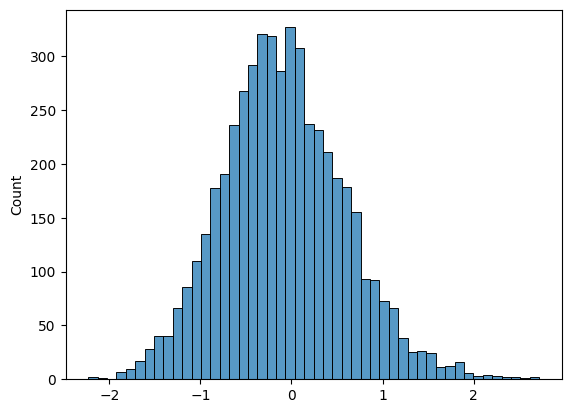

In [50]:
sns.histplot(x=word_sim_df_scaled.flatten())

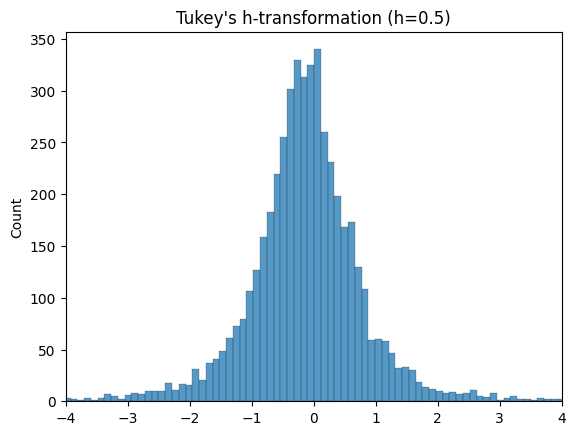

In [58]:
x = word_sim_df_scaled.flatten()
x = x[(x<3)&(x>-3)]
# h controls the stretch. 
# Try values between 0.1 (mild stretch) and 0.5 (heavy stretch)
h = 0.5

# Apply Tukey's h
x_tukey = x * np.exp((h * x**2) / 2)

sns.histplot(x=x_tukey)
# You may still need to zoom slightly if extreme outliers get stretched too far
plt.xlim(-4, 4) 
plt.title(f"Tukey's h-transformation (h={h})")
plt.show()

In [5]:
vector_mapping = {word: word_vec_df[word].values for word in word_vec_df.columns}
vector_mapping

{'SARI': array([-1.01515530e-02, -1.50101630e-02,  1.94122020e-01, -8.68961000e-03,
         1.86387450e-01,  6.87321950e-02,  7.85797760e-02,  3.02358570e-02,
        -1.28594230e-01, -8.09043900e-03,  1.51038320e-01, -6.52679100e-02,
        -9.61764600e-02, -8.53695200e-03,  4.95146500e-02,  1.36321650e-01,
        -1.86462270e-03,  3.07817440e-02, -1.31944390e-01,  6.99963100e-02,
         8.90681000e-02, -9.98033500e-02, -6.14810300e-02,  7.68673000e-03,
         1.73880850e-01, -7.46702500e-02, -4.08041000e-04,  3.59997230e-02,
        -9.66264460e-02, -1.32645280e-02, -8.33431500e-02, -1.09182030e-01,
        -1.10886030e-01, -1.95292120e-01, -1.06853120e-01, -5.30158580e-02,
         5.69991730e-02,  1.30388030e-02,  9.25044940e-02,  1.10607564e-01,
        -3.51692660e-02,  3.54002340e-02, -6.78368060e-02,  5.84219500e-02,
         9.08817000e-02,  1.04836490e-01, -1.22317360e-01,  1.04656480e-01,
         4.30367500e-02, -1.98454900e-01,  1.83687030e-01,  2.20646000e-02,
    

In [6]:
df.columns

Index(['ListID', 'Presented Word', 'Present Position', 'Recall Position',
       'Reaction Time', 'Hit', 'Participant ID', 'Participant Group'],
      dtype='object')

In [7]:
df = df.drop(df[(df["ListID"] == 0)].index, axis=0) #get rid of the training set
df["Hit"] = df["Hit"].replace(2, 0)

In [8]:
df = df.sort_values(by=["Participant Group","Participant ID", "ListID","Present Position"]) #sort
df = df.reset_index()

In [9]:
"""##Distance to Most Similar Item
#compare within lists
#use similarity matrix constructed 
last_list_id = df["ListID"][0]
last_participant_id = df["Participant ID"][0]
last_participant_group = df["Participant Group"][0]

for row in range(df.shape[0]): #iterating through rows
    # MOST SIMILAR VAL
    # MOST SIMILAR PRES DISTANCE
    while df["Participant ID"][row] == last_participant_id and df[""]"""

'##Distance to Most Similar Item\n#compare within lists\n#use similarity matrix constructed \nlast_list_id = df["ListID"][0]\nlast_participant_id = df["Participant ID"][0]\nlast_participant_group = df["Participant Group"][0]\n\nfor row in range(df.shape[0]): #iterating through rows\n    # MOST SIMILAR VAL\n    # MOST SIMILAR PRES DISTANCE\n    while df["Participant ID"][row] == last_participant_id and df[""]'

In [10]:
word_sim_df.set_index('Unnamed: 0', inplace=True)
word_sim_df.index.name = None

### Position Zone

In [11]:
df["POSITION_ZONE"] = pd.cut(
    df["Present Position"],
    bins = [0,3,14,18],
    labels=[1,2,3]
).astype(int) #divide positions to zones

### Extract Similarity

In [12]:
def find_most_similiar(group, sim_df): 
    length = len(group)-1
    similarities = []
    distances = []
    pos = []
    words = group["Presented Word"].values #get rid of pandas indexing
    
    i = 0
    while i <= length: 
        most_sim_index = i 
        current_word = words[i]
        most_sim_val = -2

        j = 0
        while j < i: 
            comparison_word = words[j]
            try: 
                similarity = sim_df.loc[current_word, comparison_word]
                if pd.notna(similarity) and similarity > most_sim_val:
                    most_sim_val, most_sim_index = similarity, j
            except KeyError: 
                print (f"{current_word} or {comparison_word} is not found on object")
                pass
            j += 1

        if most_sim_val < -1: 
            similarities.append(np.nan)
            distances.append(np.nan)
            pos.append(np.nan)
        else:
            similarities.append(most_sim_val)
            distances.append(i-most_sim_index)
            pos.append(most_sim_index)
        i += 1
    return pd.DataFrame(data = {"MOST_SIM_VAL": similarities,
                             "MOST_SIM_DIST": distances, "DEBUG_MOST_SIM_POS": pos}, index=group.index)

In [13]:
simliarity_features_vd = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(find_most_similiar, word_sim_df)
clean_features = simliarity_features_vd.droplevel([0,1,2])
df = df.join(clean_features)

C:\Users\elito\AppData\Local\Temp\ipykernel_9576\2313958469.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  simliarity_features_vd = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(find_most_similiar, word_sim_df)


In [14]:
df

,index,ListID,Presented Word,Present Position,Recall Position,Reaction Time,Hit,Participant ID,Participant Group,POSITION_ZONE,MOST_SIM_VAL,MOST_SIM_DIST,DEBUG_MOST_SIM_POS
0,3231,1,SARI,1,3.0,0.000000,1,0,eng,1,NaN,NaN,NaN
1,3232,1,KAĞIT,2,2.0,0.000000,1,0,eng,1,0.381701,1.0,0.0
2,3233,1,YAZI,3,8.0,0.000000,1,0,eng,1,0.385806,1.0,1.0
3,3234,1,EKRAN,4,NaN,NaN,0,0,eng,2,0.252005,1.0,2.0
4,3235,1,PARK,5,NaN,NaN,0,0,eng,2,0.314455,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,1495,4,KALIP,13,NaN,NaN,0,20,soc,2,0.473795,1.0,11.0
3032,1496,4,HARİTA,14,4.0,2.799603,1,20,soc,2,0.384075,12.0,1.0
3033,1497,4,SULUK,15,3.0,3.816858,1,20,soc,3,0.414580,10.0,4.0
3034,1498,4,PARA,16,2.0,2.069633,1,20,soc,3,0.428927,5.0,10.0


### Hit - Miss Feature

In [15]:
#redacted due leakage
"""#hit or miss of previous trial 
def prev_hit_miss(group): 
    length = len(group)-1
    hit_miss = []
    hit_list = group["Hit"].values #get rid of pandas indexing
    
    i = 0
    while i <= length: 
        cur = i 
        cur_val = hit_list[i]
        if i > 0:
            hit_miss.append(hit_list[i-1])
        else:
            hit_miss.append(np.nan)
        i+=1
    return pd.DataFrame(data = {"PREV_HIT_MISS": hit_miss}, index=group.index)"""

'#hit or miss of previous trial \ndef prev_hit_miss(group): \n    length = len(group)-1\n    hit_miss = []\n    hit_list = group["Hit"].values #get rid of pandas indexing\n\n    i = 0\n    while i <= length: \n        cur = i \n        cur_val = hit_list[i]\n        if i > 0:\n            hit_miss.append(hit_list[i-1])\n        else:\n            hit_miss.append(np.nan)\n        i+=1\n    return pd.DataFrame(data = {"PREV_HIT_MISS": hit_miss}, index=group.index)'

In [16]:
"""hit_miss_feature = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(prev_hit_miss)
hit_miss_feature = hit_miss_feature.droplevel([0,1,2])
df = df.join(hit_miss_feature)
df.head()"""

'hit_miss_feature = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(prev_hit_miss)\nhit_miss_feature = hit_miss_feature.droplevel([0,1,2])\ndf = df.join(hit_miss_feature)\ndf.head()'

### AVG Similarity With Previous n Words

In [17]:
def avg_sim_previous(group, sim_df, n): 
    length = len(group)
    avg_similarities = []
    words = group["Presented Word"].values 

    i = 0
    while i < length:
        current_word = words[i]
        
        # THE FIX: This determines the start of your look-back window.
        # If i=5 and n=3, start_idx is 2. (It checks j=2, 3, 4)
        # If i=1 and n=3, start_idx is 0. (It checks j=0)
        start_idx = max(0, i - n)
        
        sim_sum = 0
        valid_count = 0
        
        # Loop ONLY from the start_idx up to the current word
        j = start_idx
        while j < i:
            comparison_word = words[j]
            try:
                similarity = sim_df.loc[current_word, comparison_word]
                
                # If the similarity exists, add it to our running total
                if pd.notna(similarity):
                    sim_sum += similarity
                    valid_count += 1
            except KeyError:
                pass
            j += 1
            
        # Calculate the average. If no valid words were found (or i=0), return NaN.
        if valid_count > 0:
            avg_similarities.append(sim_sum / valid_count)
        else:
            avg_similarities.append(np.nan)
            
        i += 1
        
    # Return a DataFrame with a dynamic column name based on 'n'
    return pd.DataFrame(
        data={f"AVG_SIM_PREV_{n}": avg_similarities}, 
        index=group.index
    )

In [18]:
avg_similarity_n = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(avg_sim_previous, word_sim_df, 3)
avg_similarity_n = avg_similarity_n.droplevel([0,1,2])
df = df.join(avg_similarity_n)
df.head()

C:\Users\elito\AppData\Local\Temp\ipykernel_9576\3642068541.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_similarity_n = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(avg_sim_previous, word_sim_df, 3)


,index,ListID,Presented Word,Present Position,Recall Position,Reaction Time,Hit,Participant ID,Participant Group,POSITION_ZONE,MOST_SIM_VAL,MOST_SIM_DIST,DEBUG_MOST_SIM_POS,AVG_SIM_PREV_3
0,3231,1,SARI,1,3.0,0.0,1,0,eng,1,NaN,NaN,NaN,NaN
1,3232,1,KAĞIT,2,2.0,0.0,1,0,eng,1,0.381701,1.0,0.0,0.381701
2,3233,1,YAZI,3,8.0,0.0,1,0,eng,1,0.385806,1.0,1.0,0.325940
3,3234,1,EKRAN,4,NaN,NaN,0,0,eng,2,0.252005,1.0,2.0,0.227335
4,3235,1,PARK,5,NaN,NaN,0,0,eng,2,0.314455,3.0,1.0,0.272572


### Similarity to Last Word

In [19]:
def sim_last_word(group, sim_df): 
    length = len(group)-1
    similarities = []
    words = group["Presented Word"].values #get rid of pandas indexing
    
    i = 0
    while i <= length:
        current_word = words[i]
        if i>0: 
            comparison_word = words[i-1]
            try: 
                similarity = sim_df.loc[current_word, comparison_word]
                similarities.append(similarity)
            except KeyError: 
                similarities.append(np.nan)
        else: 
            similarities.append(np.nan)
        i += 1
    return pd.DataFrame(data = {"PREV_SIM": similarities}, index = group.index)

In [20]:
prev_word_sim = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(sim_last_word, word_sim_df)
prev_word_sim = prev_word_sim.droplevel([0,1,2])
df = df.join(prev_word_sim)
df.head()

C:\Users\elito\AppData\Local\Temp\ipykernel_9576\2403950683.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_word_sim = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(sim_last_word, word_sim_df)


,index,ListID,Presented Word,Present Position,Recall Position,Reaction Time,Hit,Participant ID,Participant Group,POSITION_ZONE,MOST_SIM_VAL,MOST_SIM_DIST,DEBUG_MOST_SIM_POS,AVG_SIM_PREV_3,PREV_SIM
0,3231,1,SARI,1,3.0,0.0,1,0,eng,1,NaN,NaN,NaN,NaN,NaN
1,3232,1,KAĞIT,2,2.0,0.0,1,0,eng,1,0.381701,1.0,0.0,0.381701,0.381701
2,3233,1,YAZI,3,8.0,0.0,1,0,eng,1,0.385806,1.0,1.0,0.325940,0.385806
3,3234,1,EKRAN,4,NaN,NaN,0,0,eng,2,0.252005,1.0,2.0,0.227335,0.252005
4,3235,1,PARK,5,NaN,NaN,0,0,eng,2,0.314455,3.0,1.0,0.272572,0.222346


### NEXT: CONTRAST
How much words semantic content differs from all the rest. 

In [21]:
import numpy as np
from scipy.spatial.distance import cosine

def contrast(group, vector_mapping, n): #of neighborhood n
    length = len(group)
    distances = []
    words = group["Presented Word"].values 

    i = 0
    while i < length:
        neighbor_vectors = []
        current_word = words[i]
        neighbors_idx_begin = max(0, i-n)
        neighbors_idx_end = min(length,i+n+1) #i = 1, n = 3, the indexes: 0 | 1 | 2, 3, 4, remove index 1 
        idx_search = [j for j in range(neighbors_idx_begin, neighbors_idx_end+1)]
        idx_search.remove(i)

        for idx in idx_search: 
            word_to_fetch = words[idx]
            try:
                vector = vector_mapping[word_to_fetch]
            except KeyError: 
                vector = np.nan
            neighbor_vectors.append(vector)
        try:
            current_word_vector = vector_mapping[current_word]
        except KeyError:
            current_word_vector = np.nan
        centroid = np.mean(neighbor_vectors, axis=0)
        dist = cosine(current_word_vector, centroid)
        distances.append(dist)
        i+=1
        
    # Return a DataFrame with a dynamic column name based on 'n'
    return pd.DataFrame(
        data={f"AVG_CONTRAST{n}": distances}, 
        index=group.index
    )

In [22]:
def contrast(group, vector_mapping, n): 
    length = len(group)
    distances = []
    words = group["Presented Word"].values
    
    i = 0
    while i < length:
        current_word = words[i]
        
        # 1. Safely fetch the target vector first. 
        # If the target word isn't in FastText, we can't calculate a distance.
        try:
            current_word_vector = vector_mapping[current_word]
        except KeyError:
            distances.append(np.nan)
            i += 1
            continue

        # 2. Safe Boundaries (prevents IndexError at the end of the list)
        # Using slice-style boundaries so we don't need +1 in the range later
        neighbors_idx_begin = max(0, i - n)
        neighbors_idx_end = min(length, i + n + 1) 
        
        neighbor_vectors = []
        
        # 3. Iterate through the safe window
        for j in range(neighbors_idx_begin, neighbors_idx_end):
            if j == i:
                continue # Skip the target word itself
                
            word_to_fetch = words[j]
            try:
                # Only add the vector if FastText actually has it
                vector = vector_mapping[word_to_fetch]
                neighbor_vectors.append(vector)
            except KeyError:
                pass
                
        # 4. Calculate Centroid and Distance
        # We must ensure we actually found valid neighbors before taking the mean
        if len(neighbor_vectors) > 0:
            centroid = np.mean(neighbor_vectors, axis=0)
            dist = cosine(current_word_vector, centroid)
            distances.append(dist)
        else:
            distances.append(np.nan)
            
        i += 1
    return pd.DataFrame(
        data={f"AVG_CONTRAST_{n}": distances}, 
        index=group.index
    )

In [23]:
contrast_df = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(contrast, vector_mapping,3)
contrast_df = contrast_df.droplevel([0,1,2])
df = df.join(contrast_df)
df.head()

C:\Users\elito\AppData\Local\Temp\ipykernel_9576\2883024779.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  contrast_df = df.groupby(["Participant ID", "Participant Group", "ListID"]).apply(contrast, vector_mapping,3)


,index,ListID,Presented Word,Present Position,Recall Position,Reaction Time,Hit,Participant ID,Participant Group,POSITION_ZONE,MOST_SIM_VAL,MOST_SIM_DIST,DEBUG_MOST_SIM_POS,AVG_SIM_PREV_3,PREV_SIM,AVG_CONTRAST_3
0,3231,1,SARI,1,3.0,0.0,1,0,eng,1,NaN,NaN,NaN,NaN,NaN,0.615852
1,3232,1,KAĞIT,2,2.0,0.0,1,0,eng,1,0.381701,1.0,0.0,0.381701,0.381701,0.504262
2,3233,1,YAZI,3,8.0,0.0,1,0,eng,1,0.385806,1.0,1.0,0.325940,0.385806,0.567887
3,3234,1,EKRAN,4,NaN,NaN,0,0,eng,2,0.252005,1.0,2.0,0.227335,0.252005,0.655217
4,3235,1,PARK,5,NaN,NaN,0,0,eng,2,0.314455,3.0,1.0,0.272572,0.222346,0.558633


In [24]:
def fatigue(group): 
    length = len(group)
    fatigue = [i for i in range(1, length+1)]
    return pd.DataFrame({"FATIGUE":fatigue}, index=group.index)

fatigue_df = df.groupby(["Participant ID", "Participant Group"]).apply(fatigue)
fatigue_df = fatigue_df.droplevel([0,1])
df = df.join(fatigue_df)
df.head()

C:\Users\elito\AppData\Local\Temp\ipykernel_9576\3272009529.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fatigue_df = df.groupby(["Participant ID", "Participant Group"]).apply(fatigue)


,index,ListID,Presented Word,Present Position,Recall Position,Reaction Time,Hit,Participant ID,Participant Group,POSITION_ZONE,MOST_SIM_VAL,MOST_SIM_DIST,DEBUG_MOST_SIM_POS,AVG_SIM_PREV_3,PREV_SIM,AVG_CONTRAST_3,FATIGUE
0,3231,1,SARI,1,3.0,0.0,1,0,eng,1,NaN,NaN,NaN,NaN,NaN,0.615852,1
1,3232,1,KAĞIT,2,2.0,0.0,1,0,eng,1,0.381701,1.0,0.0,0.381701,0.381701,0.504262,2
2,3233,1,YAZI,3,8.0,0.0,1,0,eng,1,0.385806,1.0,1.0,0.325940,0.385806,0.567887,3
3,3234,1,EKRAN,4,NaN,NaN,0,0,eng,2,0.252005,1.0,2.0,0.227335,0.252005,0.655217,4
4,3235,1,PARK,5,NaN,NaN,0,0,eng,2,0.314455,3.0,1.0,0.272572,0.222346,0.558633,5


In [25]:
df["Hit"].value_counts()

Hit
0    2058
1     978
Name: count, dtype: int64

In [26]:
df.to_csv("features_extracted.csv", encoding="utf-8-sig")

In [28]:
df["AVG_CONTRAST_3"].isna().sum()

np.int64(0)